In [1]:
from google.colab import files

uploaded = files.upload()


Saving student_suicide_dataset_5000.csv to student_suicide_dataset_5000.csv


In [2]:
import pandas as pd

df = pd.read_csv("student_suicide_dataset_5000.csv")

print("Shape:", df.shape)

df.head()

Shape: (5000, 2)


,text,label
0,I feel broken and lost after I feel lonely at ...,suicidal
1,Everything feels meaningless since I feel isol...,suicidal
2,I feel broken and lost after I lost an importa...,suicidal
3,I am mentally exhausted because I was insulted...,suicidal
4,Today I feel emotionally numb happened and I f...,suicidal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB


In [4]:
df['label'].value_counts()

,count
label,
suicidal,2508
non-suicidal,2492


In [5]:
df.isnull().sum()

,0
text,0
label,0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(5000, 2)

Columns:
Index(['text', 'label'], dtype='object')

Data Types:
text     object
label    object
dtype: object


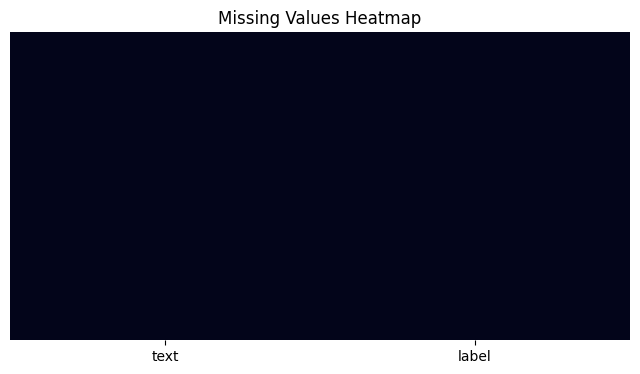

In [8]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [9]:
df.isnull().sum()

,0
text,0
label,0


In [10]:
df['text_length'] = df['text'].apply(len)

print(df['text_length'].describe())

count    5000.000000
mean      163.046800
std        44.819357
min        47.000000
25%       169.000000
50%       180.000000
75%       191.000000
max       212.000000
Name: text_length, dtype: float64


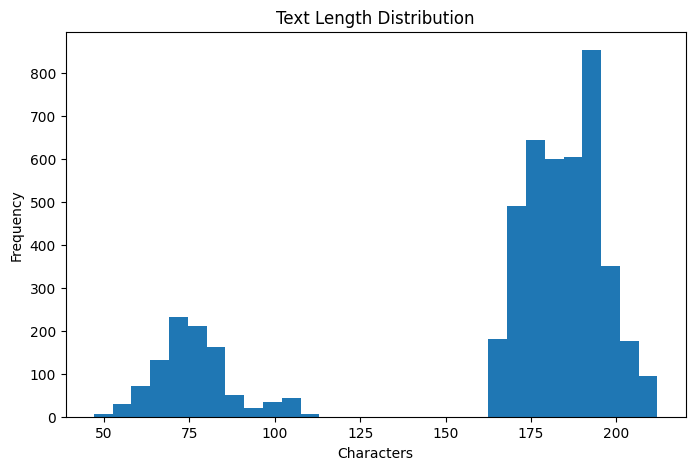

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    df['text_length'],
    bins=30
)

plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()


In [12]:
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

print(df['word_count'].describe())

count    5000.0000
mean       27.3678
std         7.1115
min        10.0000
25%        29.0000
50%        30.0000
75%        31.0000
max        35.0000
Name: word_count, dtype: float64


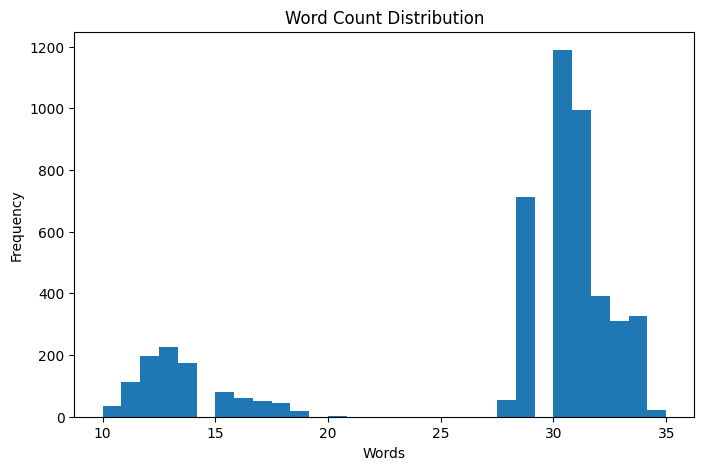

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df['word_count'],
    bins=30
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

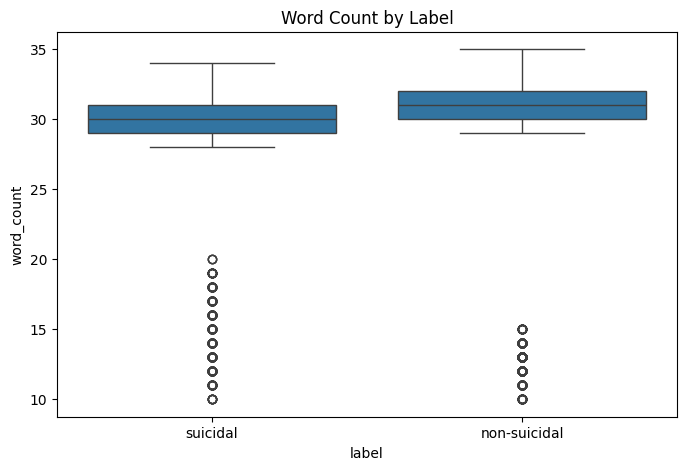

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='word_count',
    data=df
)

plt.title("Word Count by Label")

plt.show()

In [26]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [27]:
df[['text','clean_text']].head()

,text,clean_text
0,I feel broken and lost after I feel lonely at ...,feel broken lost feel lonely night evening
1,Everything feels meaningless since I feel isol...,everything feels meaningless since feel isolat...
2,I feel broken and lost after I lost an importa...,feel broken lost lost important opportunity re...
3,I am mentally exhausted because I was insulted...,mentally exhausted insulted someone today evening
4,Today I feel emotionally numb happened and I f...,today feel emotionally numb happened feel like...


In [17]:
print(df['label'].unique())

['suicidal' 'non-suicidal']


In [18]:
df['label'] = df['label'].map({
    'non-suicidal':0,
    'suicidal':1
})

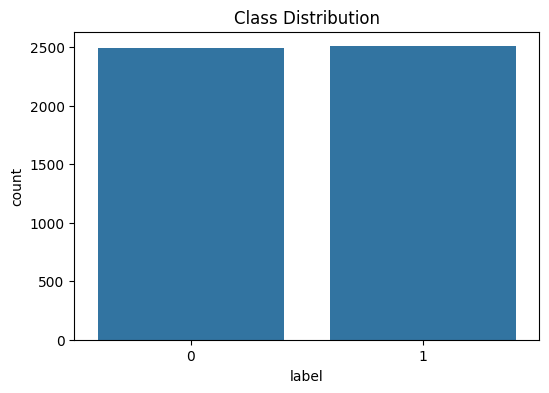

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Class Distribution")
plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

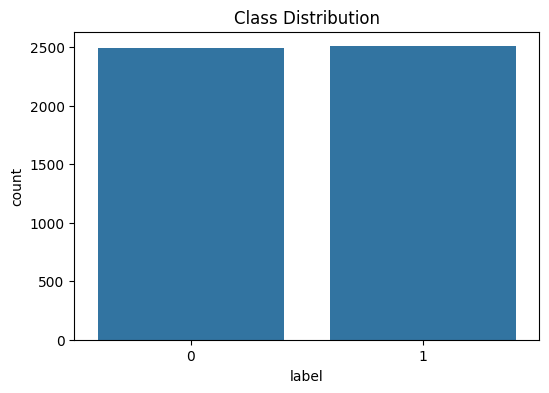

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Class Distribution")

plt.show()

In [22]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 3856


In [23]:
df.drop_duplicates(inplace=True)

In [24]:
!pip install wordcloud

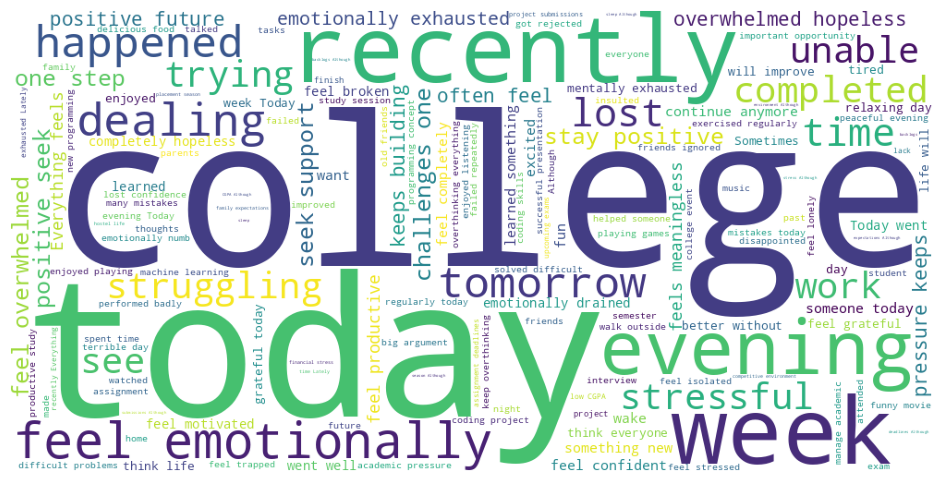

In [25]:
from wordcloud import WordCloud

text = " ".join(df['text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2)
)

X = cv.fit_transform(df['text'])

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in cv.vocabulary_.items()
]

words_freq = sorted(
    words_freq,
    key=lambda x: x[1],
    reverse=True
)

print(words_freq[:20])

[('feel emotionally', np.int64(148)), ('happened feel', np.int64(108)), ('learned new', np.int64(72)), ('stressful trying', np.int64(72)), ('trying stay', np.int64(72)), ('stay positive', np.int64(72)), ('positive seek', np.int64(72)), ('seek support', np.int64(72)), ('support work', np.int64(72)), ('work challenges', np.int64(72)), ('challenges step', np.int64(72)), ('step time', np.int64(72)), ('feel overwhelmed', np.int64(72)), ('overwhelmed hopeless', np.int64(72)), ('hopeless unable', np.int64(72)), ('unable positive', np.int64(72)), ('positive future', np.int64(72)), ('future pressure', np.int64(72)), ('pressure keeps', np.int64(72)), ('keeps building', np.int64(72))]
